# 1. Chatbot Development using tools or code.

In [ ]:
import numpy as np
import string
from nltk.corpus import stopwords
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import TfidfTransformer,TfidfVectorizer
from sklearn.pipeline import Pipeline
import nltk

In [ ]:
df = pd.read_csv('/content/dialog.txt',sep='\t')

In [ ]:
a = pd.Series(df.columns)

In [ ]:
df

,"hi, how are you doing?",i'm fine. how about yourself?
0,i'm fine. how about yourself?,i'm pretty good. thanks for asking.
1,i'm pretty good. thanks for asking.,no problem. so how have you been?
2,no problem. so how have you been?,i've been great. what about you?
3,i've been great. what about you?,i've been good. i'm in school right now.
4,i've been good. i'm in school right now.,what school do you go to?
...,...,...
3719,that's a good question. maybe it's not old age.,are you right-handed?
3720,are you right-handed?,yes. all my life.
3721,yes. all my life.,you're wearing out your right hand. stop using...
3722,you're wearing out your right hand. stop using...,but i do all my writing with my right hand.


In [ ]:
a = a.rename({0: df.columns[0],1: df.columns[1]})

In [ ]:
b = {'Questions':'Hi','Answers':'hello'}

In [ ]:
c = {'Questions':'Hello','Answers':'hi'}

In [ ]:
d= {'Questions':'how are you','Answers':"i'm fine. how about yourself?"}

In [ ]:
e= {'Questions':'how are you doing','Answers':"i'm fine. how about yourself?"}

In [ ]:
df = df.append(a,ignore_index=True)

<ipython-input-32-8a35d942b5da>:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(a,ignore_index=True)


In [ ]:
df.columns=['Questions','Answers']

In [ ]:
df = df.append([b,c,d,e],ignore_index=True)
df.head(30)

<ipython-input-34-dc34e848bcd4>:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append([b,c,d,e],ignore_index=True)


,Questions,Answers
0,i'm fine. how about yourself?,i'm pretty good. thanks for asking.
1,i'm pretty good. thanks for asking.,no problem. so how have you been?
2,no problem. so how have you been?,i've been great. what about you?
3,i've been great. what about you?,i've been good. i'm in school right now.
4,i've been good. i'm in school right now.,what school do you go to?
5,what school do you go to?,i go to pcc.
6,i go to pcc.,do you like it there?
7,do you like it there?,it's okay. it's a really big campus.
8,it's okay. it's a really big campus.,good luck with school.
9,good luck with school.,thank you very much.


In [ ]:
df = df.append(c,ignore_index=True)

<ipython-input-35-b553ed411220>:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(c,ignore_index=True)


In [ ]:
df = df.append(d,ignore_index=True)

<ipython-input-36-fb1afb7d01d1>:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(d,ignore_index=True)


In [ ]:
df = df.append(d,ignore_index=True)

<ipython-input-37-fb1afb7d01d1>:1: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(d,ignore_index=True)


In [ ]:
def cleaner(x):
    return [a for a in (''.join([a for a in x if a not in string.punctuation])).lower().split()]

In [ ]:
Pipe = Pipeline([
    ('bow',CountVectorizer(analyzer=cleaner)),
    ('tfidf',TfidfTransformer()),
    ('classifier',DecisionTreeClassifier())
])

In [ ]:
Pipe.fit(df['Questions'],df['Answers'])

Pipeline(steps=[('bow',
                 CountVectorizer(analyzer=<function cleaner at 0x7b8698ba3e20>)),
                ('tfidf', TfidfTransformer()),
                ('classifier', DecisionTreeClassifier())])

In [ ]:
Pipe.predict(['hi'])[0]

'hello'

In [ ]:
Pipe.predict(['how are you'])[0]

"i'm fine. how about yourself?"

In [ ]:
Pipe.predict(['great'])[0]

'thank you.'

In [ ]:
def chat():
    print("Chat with the bot (type 'quit' to stop)!")
    while True:
        user_input = input("You: ")
        if user_input.lower() == 'quit':
            print("ChatBot: Bye! Take care.")
            break

        response = Pipe.predict([user_input])[0]
        print("ChatBot:", response)

if __name__ == "__main__":
    nltk.download('stopwords')
    chat()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Chat with the bot (type 'quit' to stop)!
You: how are you
ChatBot: i'm fine. how about yourself?
You: i m good 
ChatBot: sorry about that.
You: what school do you go to?	
ChatBot: i go to pcc.
You: are you enjoying it there?	
ChatBot: it's not bad. there are a lot of people there.
You: quit
ChatBot: Bye! Take care.


# 2. Execute the Word2Vec and visualize the input.

In [4]:
from gensim.models import Word2Vec

sentences = [['early', 'morning', 'jogs', 'are', 'refreshing', 'and', 'healthy'],
             ['cooking', 'new', 'recipes', 'is', 'fun', 'and', 'exciting'],
             ['reading', 'books', 'expands', 'your', 'imagination'],
             ['technology', 'is', 'evolving', 'rapidly', 'every', 'day'],
             ['gardening', 'is', 'a', 'peaceful', 'and', 'rewarding', 'hobby'],
             ['music', 'brings', 'joy', 'and', 'comfort', 'to', 'many'],
             ['studying', 'history', 'helps', 'us', 'understand', 'the', 'present'],
             ['traveling', 'opens', 'up', 'new', 'worlds', 'and', 'perspectives']]


model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)


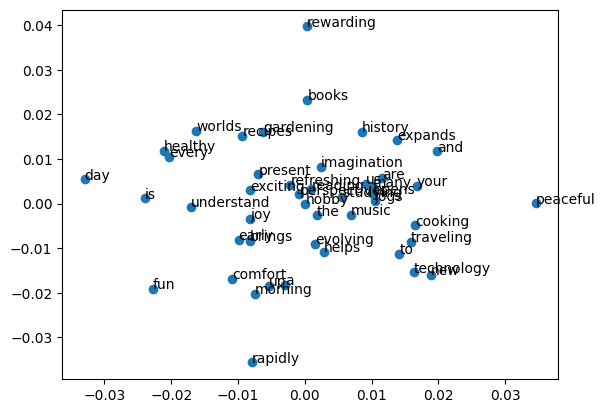

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = model.wv[model.wv.index_to_key]
pca = PCA(n_components=2)
result = pca.fit_transform(X)

plt.scatter(result[:, 0], result[:, 1])
words = list(model.wv.index_to_key)
for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))
plt.show()
